# ArgosQC SMRU Project: Config, Run QC and Upload `otnsat` DB


1. Connect to SMRU portal (requires user and password pair)
2. Download selected CIDs raw tag data (.mdb) from SMRU portal. 
3. Extract `deployments` table from SMRU for observation.
3. Map tag locations to identify and exclude the tags from continuous pipeline.
4. Generate configuration files for ArgosQC.smru_qc().

In [1]:
from py_nrt import argos_smru_project_config as aspc
from py_nrt import common
import itables

# Excutable for mdb tables tool. Set to empty string for Windows
mdb_tables_path = ''
qc_input_path = r'input'
qc_output_path = r'qc'
exclude_tag_ref = []
# (Optional) Set to True to see API payload and response.
verbose=False

program_dropdown = common.show_program_dropdown()
upload_mode_radio = aspc.show_data_upload_mode_radio()
cid_textbox = aspc.show_cid_textbox()
collectioncode_textbox = aspc.show_collectioncode_textbox()

/opt/miniconda3/envs/rt-sat-to-obis/lib/python3.11/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.20) or chardet (7.3.0)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


HTML(value='<h3 style="margin: 0; color: blue;">Please select a program:</h3>')

Combobox(value='', options=('otn', 'imos', 'atn'), placeholder='Select a Program')

HTML(value='<h3 style="margin: 0; color: blue;">Please choose project status:</h3>')

RadioButtons(options=('Ongoing: near real-time mode', 'Completed: delay mode'), value=None)

HTML(value='<h3 style="margin: 0; color: blue;">SMRU campaign ID:</h3>')

Text(value='', description='Campaign ID:', layout=Layout(width='400px'), placeholder='SMRU Campaign ID')

HTML(value='<h3 style="margin: 0; color: blue;">(Optional) OTN project collectioncode.</h3>')

HTML(value='For projects already loaded into the OTN node. Otherwise leave it as "unknown".')

Text(value='unknown', layout=Layout(width='400px'), placeholder='OTN project collectioncode')

## 1. Get `cid`.mdb file from SMRU portal or local upload


In [2]:
program, upload_mode, cid, collectioncode = aspc.get_user_input(
    {'program': program_dropdown, 'upload_mode': upload_mode_radio, 'cid': cid_textbox, 'collectioncode': collectioncode_textbox})
smru_user_text, smru_password_text = aspc.show_smru_login(qc_input_path, program, upload_mode, cid, collectioncode)

Delay mode found vc08.mdb file in below folder: input/otn/otn_vc08/mdb


HTML(value='<a href="https://jphub.oceantrack.org/user/satnrt/tree/rt-sat-to-obis/input/otn/otn_vc08/mdb" targ…

## 2. Extract `deployments` table for observation

### Requires `mdbtools` 
1. For Windows 
    - Download the `mdbtools-app` folder from https://github.com/apelsito/mdb-tools-for-windows/tree/main 
    - Save into `C:\mdbtools-app` and add to system path.
    - To test: in a `cmd` terminal type `mdb-tables --help`. Expected output:
    ```
        option parsing failed: Unrecognized option: --help.
        Usage:
          mdb-util [OPTIONa€|] <file> - show MDB files tables/entries
        ...
    ```
2. For Mac: 
    - Intall mdbtools: `brew install mdbtools`
    - It should be added into PATH. To verify: `which mdb-export`
    

In [3]:
if smru_user_text and smru_password_text:
    aspc.smru_get_mdb(program, cid, smru_user_text.value, smru_password_text.value, qc_input_path, collectioncode, 120, True)
# Extract deployments table from <cid>.mdb file.
cid_mdb, deployment_df = aspc.extract_deployments(program, cid, qc_input_path, verbose=verbose)
if upload_mode == 'delay':
    aspc.export_deployment_for_argosqc(program, cid, deployment_df, qc_input_path)

Running command: mdb-export input/otn/otn_vc08/mdb/vc08.mdb deployments


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


### 2.1 Identify invalid tag(s) to be excluded (note the REFs) from above table.
- If the preject has been create on OTN node, find matching tags in OTN project schema.otn_sat_tags and list tags to be excluded in `exclude_tag_ref` and go to Step 5.
- Otherwise, use step 3 and step 4 to determin tags to be excluded.

In [5]:
exclude_tag_ref = []

## 3. (Optional) Extract tracks (from the raw `ctd` table) for visualization


In [6]:
cid_mdb, tracks_df = aspc.extract_tacks(program, cid, qc_input_path, exclude_tag_ref, verbose=verbose)
# (Optional) specify a sebset of tags (REF) to export. Leave subset_tags = [] to export all tags
subset_tags = [ 'vc08-VMT400-21']
subset_tag_tracks_df = aspc.export_for_kepler(cid, tracks_df, subset_tags)

Running command: mdb-export input/otn/otn_vc08/mdb/vc08.mdb diag
Showing min and max dates rows in the "diag" table for each REF (12 out of 27674) rows,


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


## 4. (Optional) Visualize Tracks (Raw Data) - Helps to Determine which Tags to be excluded

4.1 Click the `CSV` button in above cell and download `<cid>_tracks_<yyyymmdd>.csv`

4.2 Go to a kepler.gl viewer instance https://kepler.gl/demo or http://localhost:8000/ via SSH tunnel to JPhub

`ssh -L 8000:localhost:8000  -i <your_ssl_pk_file> <your_user>@jphub.oceantrack.org`

See https://gitlab.oceantrack.org/otn-partner-nodes/jphub/-/wikis/Host-and-Use-Kepler.gl-Viewer-on-JPhub

4.3 Upload data `<cid>_tracks_<yyyymmdd>.csv`

4.4 Click `Add Layer`: under `Basic` select `Point`; under `Color based on` select `tag_req`

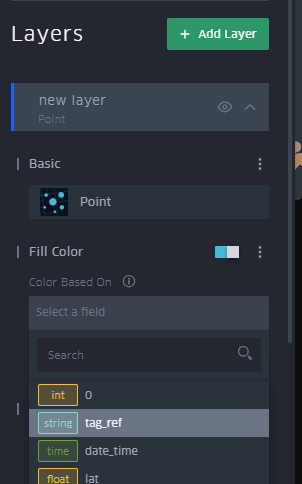

4.5 In Filters tab, click `Add Filter` select `date_time`

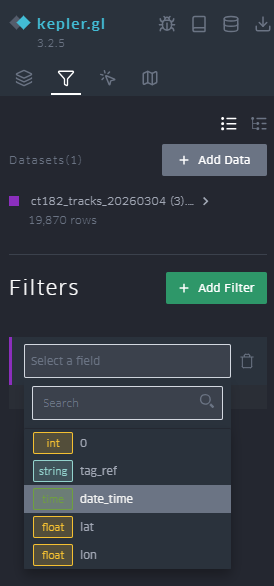

4.6 Adjust rolling window and click the play button
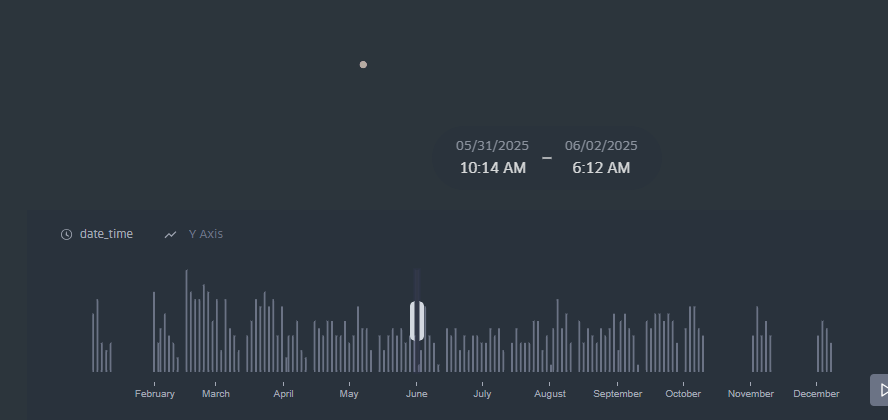

## 5. Generate smru_qc Configuration Files

### All Configuration Parameters for SSM Model and QC Process See: 

1. Node Manager Training: 

https://github.com/ocean-tracking-network/node-manager-training/blob/nrt-ArgosQC/_episodes/30_near_real_time_qc_process.md

2. ArgosQC vignette: 

https://github.com/ianjonsen/ArgosQC/blob/main/vignettes/WC_config_file.Rmd

https://github.com/ianjonsen/ArgosQC/blob/main/vignettes/SMRU_workflow.Rmd

### Required Parameters:
#### `time_step` (hours): adjust value (usually between 1 to 10) according to tagged animal's species.
#### `common_name` and `species`

### Observe and Modify Configuration File(s) as Needed

- Example configuration file (json):

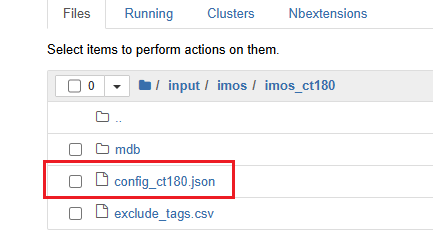


In [ ]:
# Default settings
time_step = 3
download =  False if (not user) and (not password) else True

# Campaign specific settings
common_name = 'grey seal'
species = 'Halichoerus grypus'
release_site = 'Hay Island'
state_country = 'Nova Scotia Canada'

output_files = aspc.create_smru_qc_config(
    program = program,
    cid = cid,
    drop_ids = exclude_tag_ref,
    otn_collection_code = otn_collection_code,
    qc_input_path = qc_input_path,
    qc_output_path=qc_output_path,
    mdb_tables_path=mdb_tables_path,
    user=user, 
    password=password, 
    time_step=time_step,
    download=download,
    common_name=common_name,
    species=species,
    release_site=release_site,
    state_country=state_country
)


## 6. Run ArgosQC for Configured Project

In [7]:
r_executable = '/opt/R/4.5.2/bin/Rscript'
config_file = 'input/otn/otn_vc08/config_vc08.json'
aspc.run_smru_qc(r_executable, config_file, argosqc_r_sript = 'r_nrt/run_ArgosQC_smru_qc.R')

Running ArgosQC: /opt/R/4.5.2/bin/Rscript r_nrt/run_ArgosQC_smru_qc.R input/otn/otn_vc08/config_vc08.json

Loading required package: ArgosQC

Loading required package: jsonlite

Reading tag data from .mdb file...

sh: line 1: C:/Users/hpz2/mdbtools-app/mdb-tables: No such file or directory
[1] "2026-07-10 14:34:56 UTC"
Error in system(cmd_tables, intern = TRUE) : error in running command

In addition: Warning message:
[1] ‘0.9.17’
Unknown or uninitialised column: `ref`. 
[1] "input/otn/otn_vc08/config_vc08.json"
Error in smru$diag : $ operator is invalid for atomic vectors
Calls: smru_qc -> smru_pull_tables -> summarise -> group_by
Execution halted
ArgosQC failed with return code: 1


## 7. Evaluate ArgosQC Resluts

### After smru_qc is done find ssm output file in qc/\<program>/\<program>_\<cid>/

e.g. qc/imos/imos_ct182/\*ssmoutputs\*_nrt.csv

In [ ]:
subset_tags = [ 'ct182-890C-I2C-24']
tag_ssmoutput_df = aspc.extract_ssmoutput_tracks(program, cid, qc_output_path, subset_tags, verbose=verbose)


## 8. Visualize SSM Output with Raw Tracks - Helps to Verify and Improve Model Perforamce

8.1 Click the CSV button in above cell and download <cid>_ssmoutput_<yyyymmdd>.csv

8.2 Upload data `<cid>_ssmoutput_<yyyymmdd>.csv` in the same kepler.gl viewer.
    
8.3 Add a Point Layer and Fill Color by `tag_ref`
    
   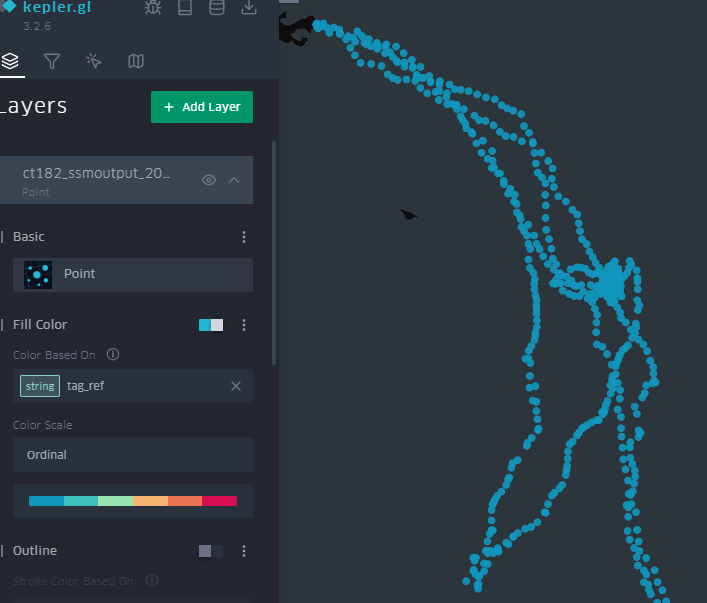
    
8.4 Toggle raw and ssmoutput layers for static observation
    
  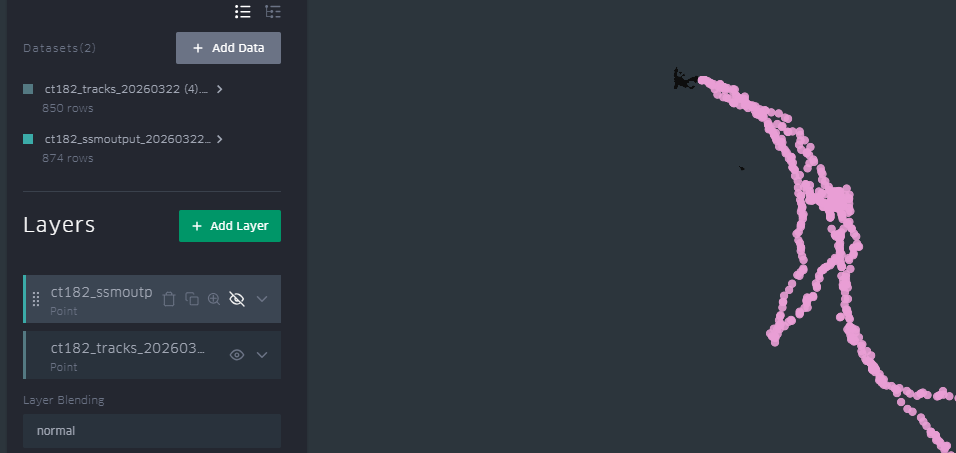
    
8.4 In Filters tab click Synced datasets and select <cid>_ssmoutput_<yyyymmdd>.csv
    
   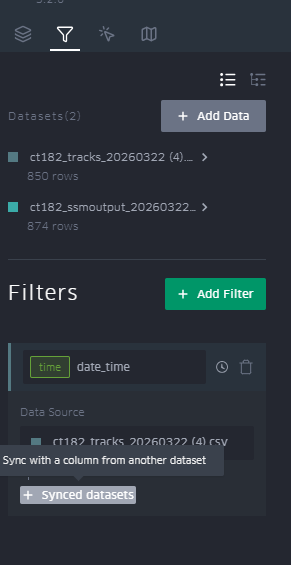
    
8.5 Adjust sliding window on the bottom and compare raw and QCed animal locations over time.
    
 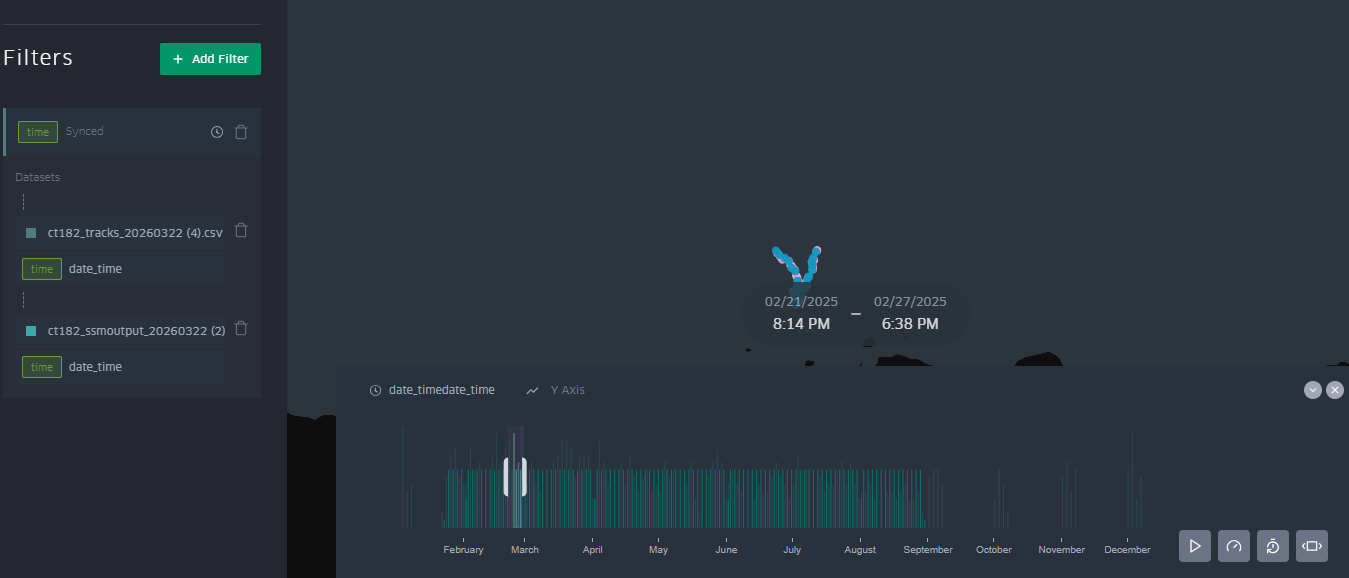